In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")


## Analysis of ERM, JTT and Disent

Add new datasets as needed

In [37]:
DATASET_CONFIG = {
    "waterbirds": {
        "y_map": {
            0: "landbird",
            1: "waterbird",
        },
        "attr_map": {
            0: "land",
            1: "water",
        },
        "spurious_aligned": lambda y, a: (
            (y == 1 and a == 1) or (y == 0 and a == 0)
        ),
        "groups": [
            (1, 1, "Waterbird–Water"),
            (1, 0, "Waterbird–Land"),
            (0, 0, "Landbird–Land"),
            (0, 1, "Landbird–Water"),
        ],
    },
    "fairface": {
        "y_map": {
            0: "female",
            1: "male",
        },
        "attr_map": {
            0: "black",
            1: "white",
        },
        "spurious_aligned": lambda y, a: (
            (y == 1 and a == 1) or (y == 0 and a == 0)
        ),
        "groups": [
            (1, 1, "Male–White"),
            (1, 0, "Male–Black"),
            (0, 0, "Female–Black"),
            (0, 1, "Female–White"),
        ],
    }
}

In [38]:
def load_eval_csv(method_name, dataset_name, worst_group=False):
    if worst_group:
        return pd.read_csv(f"{method_name}_{dataset_name}_worst_group_results.csv")
    return pd.read_csv(f"{method_name}_{dataset_name}_avg_results.csv")

In [39]:
# Load evaluation results for Waterbirds dataset
df_erm = load_eval_csv("resnet", "waterbirds")
df_jtt = load_eval_csv("jtt", "waterbirds")
df_disent = load_eval_csv("disent", "waterbirds")
df_debiasify = load_eval_csv("debiasify", "waterbirds")

df_erm_worst = load_eval_csv("resnet", "waterbirds", worst_group=True)
df_jtt_worst = load_eval_csv("jtt", "waterbirds", worst_group=True)
df_disent_worst = load_eval_csv("disent", "waterbirds", worst_group=True)
df_debiasify_worst = load_eval_csv("debiasify", "waterbirds", worst_group=True)

In [40]:
# Load evaluation results for FairFace dataset
df_erm_ff = load_eval_csv("resnet", "fairface")
df_jtt_ff = load_eval_csv("jtt", "fairface")
df_disent_ff = load_eval_csv("disent", "fairface")
df_debiasify_ff = load_eval_csv("debiasify", "fairface")


df_erm_ff_worst = load_eval_csv("resnet", "fairface", worst_group=True)
df_jtt_ff_worst = load_eval_csv("jtt", "fairface", worst_group=True)
df_disent_ff_worst = load_eval_csv("disent", "fairface", worst_group=True)
df_debiasify_ff_worst = load_eval_csv("debiasify", "fairface", worst_group=True)

In [41]:
def add_confidence_columns(df, dataset_name):
    cfg = DATASET_CONFIG[dataset_name]

    df = df.copy()

    # confidence in true class
    df["p_true"] = df.apply(
        lambda r: r.p_1 if r.y_true == 1 else r.p_0,
        axis=1
    )

    # spurious alignment
    df["spurious"] = df.apply(
        lambda r: cfg["spurious_aligned"](r.y_true, r.attr_true),
        axis=1
    )

    return df

### Accuracy Table

In [42]:
def table_group_accuracy(df, method_name, dataset_name):
    cfg = DATASET_CONFIG[dataset_name]

    rows = []

    # overall
    rows.append({
        "Method": method_name,
        "Group": "Overall",
        "Accuracy": df["correct"].mean(),
    })

    # group-wise
    for y, a, group_name in cfg["groups"]:
        mask = (df.y_true == y) & (df.attr_true == a)
        acc = df.loc[mask, "correct"].mean()
        rows.append({
            "Method": method_name,
            "Group": group_name,
            "Accuracy": acc,
        })

    return pd.DataFrame(rows)

# Waterbirds average accuracy table
pd.concat([
    table_group_accuracy(df_erm, "ERM", "waterbirds"),
    table_group_accuracy(df_jtt, "JTT", "waterbirds"),
    table_group_accuracy(df_disent, "DisEnt", "waterbirds"),
    table_group_accuracy(df_debiasify, "Debiasify", "waterbirds"),
])


,Method,Group,Accuracy
0,ERM,Overall,0.820225
1,ERM,Waterbird–Water,0.958042
2,ERM,Waterbird–Land,0.638889
3,ERM,Landbird–Land,0.983740
4,ERM,Landbird–Water,0.709677
0,JTT,Overall,0.855805
1,JTT,Waterbird–Water,0.951049
2,JTT,Waterbird–Land,0.819444
3,JTT,Landbird–Land,0.926829
4,JTT,Landbird–Water,0.717742


In [43]:
# Waterbirds worst group accuracy
pd.concat([
    table_group_accuracy(df_erm_worst, "ERM", "waterbirds"),
    table_group_accuracy(df_jtt_worst, "JTT", "waterbirds"),
    table_group_accuracy(df_disent_worst, "DisEnt", "waterbirds"),
    table_group_accuracy(df_debiasify_worst, "Debiasify", "waterbirds"),
])

,Method,Group,Accuracy
0,ERM,Overall,0.782772
1,ERM,Waterbird–Water,0.951049
2,ERM,Waterbird–Land,0.597222
3,ERM,Landbird–Land,0.967480
4,ERM,Landbird–Water,0.620968
0,JTT,Overall,0.831461
1,JTT,Waterbird–Water,0.881119
2,JTT,Waterbird–Land,0.819444
3,JTT,Landbird–Land,0.861789
4,JTT,Landbird–Water,0.758065


In [44]:
# FairFace average accuracy
pd.concat([
    table_group_accuracy(df_erm_ff, "ERM", "fairface"),
    table_group_accuracy(df_jtt_ff, "JTT", "fairface"),
    table_group_accuracy(df_disent_ff, "DisEnt", "fairface"),
    table_group_accuracy(df_debiasify_ff, "Debiasify", "fairface"),
])

,Method,Group,Accuracy
0,ERM,Overall,0.728170
1,ERM,Male–White,0.954453
2,ERM,Male–Black,0.494753
3,ERM,Female–Black,0.932551
4,ERM,Female–White,0.498894
0,JTT,Overall,0.709658
1,JTT,Male–White,0.880567
2,JTT,Male–Black,0.535232
3,JTT,Female–Black,0.828446
4,JTT,Female–White,0.561947


In [45]:
# FairFace worst group accuracy
pd.concat([
    table_group_accuracy(df_erm_ff_worst, "ERM", "fairface"),
    table_group_accuracy(df_jtt_ff_worst, "JTT", "fairface"),
    table_group_accuracy(df_disent_ff_worst, "DisEnt", "fairface"),
    table_group_accuracy(df_debiasify_ff_worst, "Debiasify", "fairface"),
])

,Method,Group,Accuracy
0,ERM,Overall,0.728170
1,ERM,Male–White,0.954453
2,ERM,Male–Black,0.494753
3,ERM,Female–Black,0.932551
4,ERM,Female–White,0.498894
0,JTT,Overall,0.634064
1,JTT,Male–White,0.624494
2,JTT,Male–Black,0.625187
3,JTT,Female–Black,0.629032
4,JTT,Female–White,0.654867


### Confusion Matrix Correctness x Spurious

In [ ]:
def is_spurious(cfg, row):
    return cfg["spurious_aligned"](row.y_true, row.attr_true)

def table_confusion_spurious(df, method_name, dataset_name):
    cfg = DATASET_CONFIG[dataset_name]

    df = df.copy()
    df["spurious"] = df.apply(lambda row: is_spurious(cfg, row), axis=1)

    rows = [{
        "Method": method_name,
        "Conf(correct, spurious)": ((df.correct == 1) & (df.spurious)).mean(),
        "Conf(correct, non-spurious)": ((df.correct == 1) & (~df.spurious)).mean(),
        "Conf(wrong, spurious)": ((df.correct == 0) & (df.spurious)).mean(),
        "Conf(wrong, non-spurious)": ((df.correct == 0) & (~df.spurious)).mean(),
    }]

    return pd.DataFrame(rows)

# Waterbirds average confusion table by spurious alignment
pd.concat([
    table_confusion_spurious(df_erm, "ERM", "waterbirds"),
    table_confusion_spurious(df_jtt, "JTT", "waterbirds"),
    table_confusion_spurious(df_disent, "DisEnt", "waterbirds"),
    table_confusion_spurious(df_debiasify, "Debiasify", "waterbirds"),
])


,Method,"Conf(correct, spurious)","Conf(correct, non-spurious)","Conf(wrong, spurious)","Conf(wrong, non-spurious)"
0,ERM,0.483146,0.337079,0.014981,0.164794
0,JTT,0.468165,0.387640,0.029963,0.114232
0,DisEnt,0.468165,0.385768,0.029963,0.116105
0,Debiasify,0.477528,0.361423,0.020599,0.140449


In [47]:
# Waterbirds worst group confusion table by spurious alignment
pd.concat([
    table_confusion_spurious(df_erm_worst, "ERM", "waterbirds"),
    table_confusion_spurious(df_jtt_worst, "JTT", "waterbirds"),
    table_confusion_spurious(df_disent_worst, "DisEnt", "waterbirds"),
    table_confusion_spurious(df_debiasify_worst, "Debiasify", "waterbirds"),
])


,Method,"Conf(correct, spurious)","Conf(correct, non-spurious)","Conf(wrong, spurious)","Conf(wrong, non-spurious)"
0,ERM,0.477528,0.305243,0.020599,0.196629
0,JTT,0.434457,0.397004,0.063670,0.104869
0,DisEnt,0.434457,0.398876,0.063670,0.102996
0,Debiasify,0.483146,0.370787,0.014981,0.131086


In [48]:
# FairFace average confusion table by spurious alignment
pd.concat([
    table_confusion_spurious(df_erm_ff, "ERM", "fairface"),
    table_confusion_spurious(df_jtt_ff, "JTT", "fairface"),
    table_confusion_spurious(df_disent_ff, "DisEnt", "fairface"),
    table_confusion_spurious(df_debiasify_ff, "Debiasify", "fairface"),
])

,Method,"Conf(correct, spurious)","Conf(correct, non-spurious)","Conf(wrong, spurious)","Conf(wrong, non-spurious)"
0,ERM,0.487195,0.240975,0.028078,0.243752
0,JTT,0.442765,0.266893,0.072508,0.217834
0,DisEnt,0.449553,0.292194,0.065720,0.192533
0,Debiasify,0.490281,0.241592,0.024992,0.243135


In [49]:
# FairFace worst group confusion table by spurious alignment
pd.concat([
    table_confusion_spurious(df_erm_ff_worst, "ERM", "fairface"),
    table_confusion_spurious(df_jtt_ff_worst, "JTT", "fairface"),
    table_confusion_spurious(df_disent_ff_worst, "DisEnt", "fairface"),
    table_confusion_spurious(df_debiasify_ff_worst, "Debiasify", "fairface"),
])

,Method,"Conf(correct, spurious)","Conf(correct, non-spurious)","Conf(wrong, spurious)","Conf(wrong, non-spurious)"
0,ERM,0.487195,0.240975,0.028078,0.243752
0,JTT,0.322740,0.311324,0.192533,0.173403
0,DisEnt,0.370565,0.336933,0.144708,0.147794
0,Debiasify,0.491206,0.251466,0.024067,0.233261


### Error Analysis Table

In [50]:
def table_error_attribution(df, method_name, dataset_name):
    cfg = DATASET_CONFIG[dataset_name]

    df = df.copy()
    df["spurious"] = df.apply(lambda row: is_spurious(cfg, row), axis=1)

    total_errors = (df.correct == 0).sum()
    errors_spurious = ((df.correct == 0) & (df.spurious)).sum()
    errors_non_spurious = ((df.correct == 0) & (~df.spurious)).sum()

    rows = [{
        "Method": method_name,
        "Total Errors": total_errors,
        "Errors on Spurious": errors_spurious,
        "Errors on Non-Spurious": errors_non_spurious,
        "% Errors from Spurious": errors_spurious / total_errors if total_errors > 0 else 0.0,
        "% Errors from Non-Spurious": errors_non_spurious / total_errors if total_errors > 0 else 0.0,
    }]

    return pd.DataFrame(rows)

# Waterbirds average error attribution
pd.concat([
    table_error_attribution(df_erm, "ERM", "waterbirds"),
    table_error_attribution(df_jtt, "JTT", "waterbirds"),
    table_error_attribution(df_disent, "DisEnt", "waterbirds"),
    table_error_attribution(df_debiasify, "Debiasify", "waterbirds"),
])

,Method,Total Errors,Errors on Spurious,Errors on Non-Spurious,% Errors from Spurious,% Errors from Non-Spurious
0,ERM,96,8,88,0.083333,0.916667
0,JTT,77,16,61,0.207792,0.792208
0,DisEnt,78,16,62,0.205128,0.794872
0,Debiasify,86,11,75,0.127907,0.872093


In [51]:
# Waterbirds worst group error attribution
pd.concat([
    table_error_attribution(df_erm_worst, "ERM", "waterbirds"),
    table_error_attribution(df_jtt_worst, "JTT", "waterbirds"),
    table_error_attribution(df_disent_worst, "DisEnt", "waterbirds"),
    table_error_attribution(df_debiasify_worst, "Debiasify", "waterbirds"),
])

,Method,Total Errors,Errors on Spurious,Errors on Non-Spurious,% Errors from Spurious,% Errors from Non-Spurious
0,ERM,116,11,105,0.094828,0.905172
0,JTT,90,34,56,0.377778,0.622222
0,DisEnt,89,34,55,0.382022,0.617978
0,Debiasify,78,8,70,0.102564,0.897436


In [52]:
# FairFace average error attribution
pd.concat([
    table_error_attribution(df_erm_ff, "ERM", "fairface"),
    table_error_attribution(df_jtt_ff, "JTT", "fairface"),
    table_error_attribution(df_disent_ff, "DisEnt", "fairface"),
    table_error_attribution(df_debiasify_ff, "Debiasify", "fairface"),
])

,Method,Total Errors,Errors on Spurious,Errors on Non-Spurious,% Errors from Spurious,% Errors from Non-Spurious
0,ERM,881,91,790,0.103292,0.896708
0,JTT,941,235,706,0.249734,0.750266
0,DisEnt,837,213,624,0.254480,0.745520
0,Debiasify,869,81,788,0.093211,0.906789


In [53]:
# FairFace worst group error attribution
pd.concat([
    table_error_attribution(df_erm_ff_worst, "ERM", "fairface"),
    table_error_attribution(df_jtt_ff_worst, "JTT", "fairface"),
    table_error_attribution(df_disent_ff_worst, "DisEnt", "fairface"),
    table_error_attribution(df_debiasify_ff_worst, "Debiasify", "fairface"),
])

,Method,Total Errors,Errors on Spurious,Errors on Non-Spurious,% Errors from Spurious,% Errors from Non-Spurious
0,ERM,881,91,790,0.103292,0.896708
0,JTT,1186,624,562,0.526138,0.473862
0,DisEnt,948,469,479,0.494726,0.505274
0,Debiasify,834,78,756,0.093525,0.906475


### Confidence in True Class on Correct vs Wrong Predictions

In [54]:
def table_confidence_correct_wrong(df, method_name, dataset_name):
    df = add_confidence_columns(df, dataset_name)
    rows = [{
        "Method": method_name,
        "Mean conf (correct)": df[df["correct"] == 1]["p_true"].mean(),
        "Mean conf (wrong)": df[df["correct"] == 0]["p_true"].mean(),
        "Confidence gap": (
            df[df["correct"] == 1]["p_true"].mean()
            - df[df["correct"] == 0]["p_true"].mean()
        )
    }]

    return pd.DataFrame(rows)

# Waterbirds average confidence for correct vs wrong predictions
pd.concat([
    table_confidence_correct_wrong(df_erm, "ERM", "waterbirds"),
    table_confidence_correct_wrong(df_jtt, "JTT", "waterbirds"),
    table_confidence_correct_wrong(df_disent, "DisEnt", "waterbirds"),
    table_confidence_correct_wrong(df_debiasify, "Debiasify", "waterbirds"),
])


,Method,Mean conf (correct),Mean conf (wrong),Confidence gap
0,ERM,0.965634,0.102527,0.863107
0,JTT,0.912973,0.193686,0.719287
0,DisEnt,0.929182,0.220878,0.708304
0,Debiasify,0.960894,0.134459,0.826435


In [55]:
# Waterbirds worst group confidence for correct vs wrong predictions
pd.concat([
    table_confidence_correct_wrong(df_erm_worst, "ERM", "waterbirds"),
    table_confidence_correct_wrong(df_jtt_worst, "JTT", "waterbirds"),
    table_confidence_correct_wrong(df_disent_worst, "DisEnt", "waterbirds"),
    table_confidence_correct_wrong(df_debiasify_worst, "Debiasify", "waterbirds"),
])

,Method,Mean conf (correct),Mean conf (wrong),Confidence gap
0,ERM,0.972198,0.091990,0.880208
0,JTT,0.880602,0.269358,0.611243
0,DisEnt,0.878528,0.268751,0.609777
0,Debiasify,0.955809,0.119896,0.835913


In [56]:
# FairFace average confidence for correct vs wrong predictions
pd.concat([
    table_confidence_correct_wrong(df_erm_ff, "ERM", "fairface"),
    table_confidence_correct_wrong(df_jtt_ff, "JTT", "fairface"),
    table_confidence_correct_wrong(df_disent_ff, "DisEnt", "fairface"),
    table_confidence_correct_wrong(df_debiasify_ff, "Debiasify", "fairface"),
])

,Method,Mean conf (correct),Mean conf (wrong),Confidence gap
0,ERM,0.968689,0.075299,0.893389
0,JTT,0.874066,0.213949,0.660117
0,DisEnt,0.904785,0.188424,0.716360
0,Debiasify,0.882747,0.232564,0.650182


In [57]:
# FairFace worst group confidence for correct vs wrong predictions
pd.concat([
    table_confidence_correct_wrong(df_erm_ff_worst, "ERM", "fairface"),
    table_confidence_correct_wrong(df_jtt_ff_worst, "JTT", "fairface"),
    table_confidence_correct_wrong(df_disent_ff_worst, "DisEnt", "fairface"),
    table_confidence_correct_wrong(df_debiasify_ff_worst, "Debiasify", "fairface"),
])

,Method,Mean conf (correct),Mean conf (wrong),Confidence gap
0,ERM,0.968689,0.075299,0.893389
0,JTT,0.847351,0.198933,0.648418
0,DisEnt,0.866450,0.222630,0.643820
0,Debiasify,0.886410,0.215761,0.670650


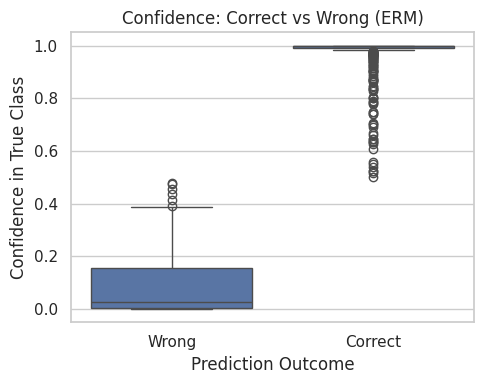

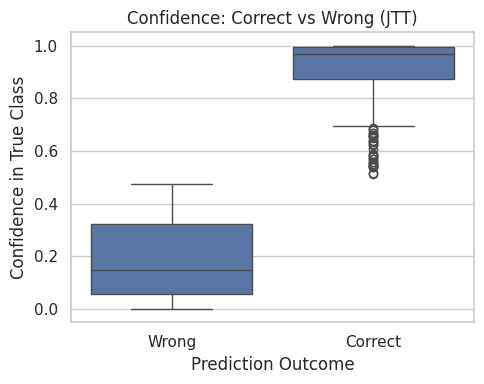

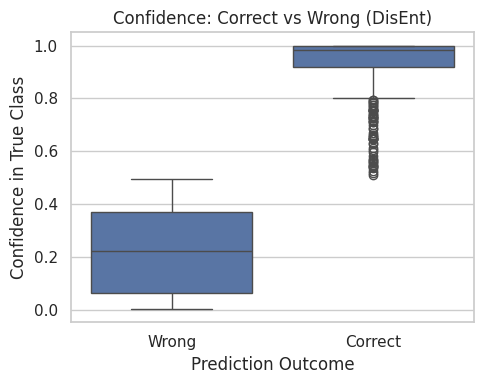

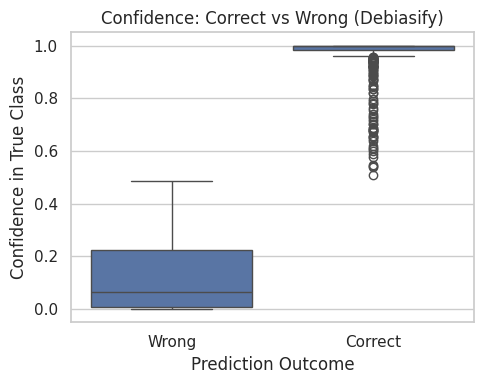

In [58]:
def plot_confidence_correct_wrong(df, method_name, dataset_name):
    df = add_confidence_columns(df, dataset_name)

    plt.figure(figsize=(5,4))
    sns.boxplot(
        data=df,
        x="correct",
        y="p_true"
    )
    plt.xticks([0,1], ["Wrong", "Correct"])
    plt.xlabel("Prediction Outcome")
    plt.ylabel("Confidence in True Class")
    plt.title(f"Confidence: Correct vs Wrong ({method_name})")
    plt.tight_layout()
    plt.show()

# Waterbirds average confidence for correct vs wrong predictions
plot_confidence_correct_wrong(df_erm, "ERM", "waterbirds")
plot_confidence_correct_wrong(df_jtt, "JTT", "waterbirds")
plot_confidence_correct_wrong(df_disent, "DisEnt", "waterbirds")   
plot_confidence_correct_wrong(df_debiasify, "Debiasify", "waterbirds")

### Confidence on Spurious vs Non-Spurious


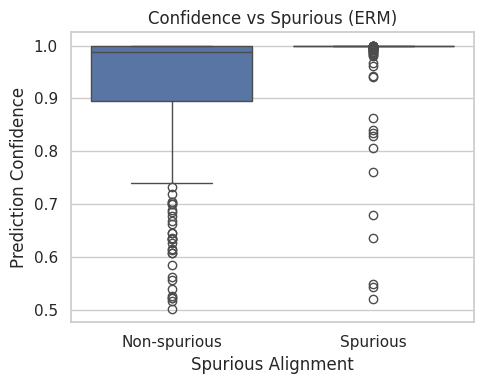

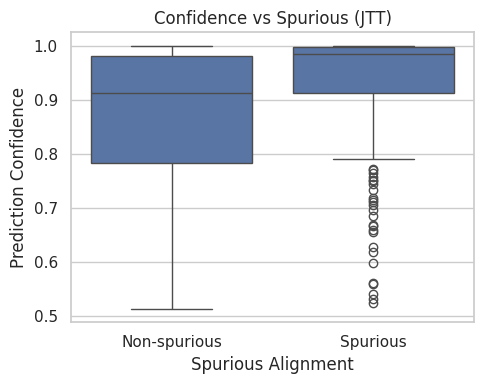

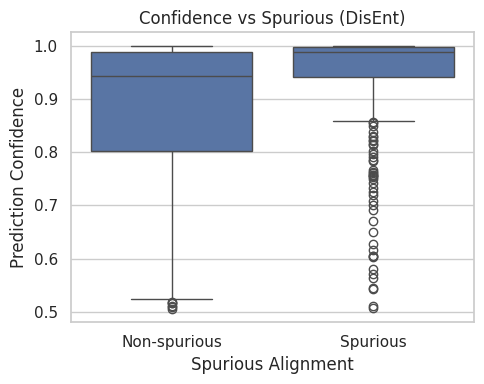

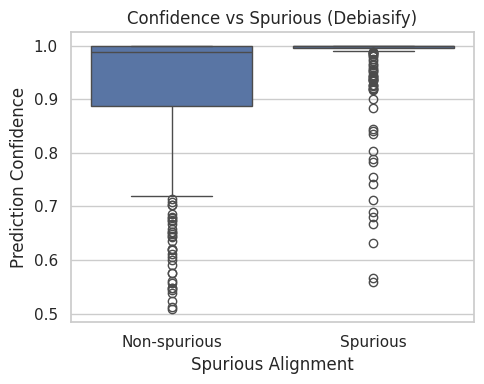

In [59]:
def plot_confidence_spurious(df, method_name, dataset_name):
    df = add_confidence_columns(df, dataset_name)

    plt.figure(figsize=(5,4))
    sns.boxplot(
        data=df,
        x="spurious",
        y="p_max"
    )
    plt.xticks([0,1], ["Non-spurious", "Spurious"])
    plt.xlabel("Spurious Alignment")
    plt.ylabel("Prediction Confidence")
    plt.title(f"Confidence vs Spurious ({method_name})")
    plt.tight_layout()
    plt.show()

# Waterbirds average confidence by spurious alignment
plot_confidence_spurious(df_erm, "ERM", "waterbirds")
plot_confidence_spurious(df_jtt, "JTT", "waterbirds")
plot_confidence_spurious(df_disent, "DisEnt", "waterbirds") 
plot_confidence_spurious(df_debiasify, "Debiasify", "waterbirds")

### Conflict-Only Confidence

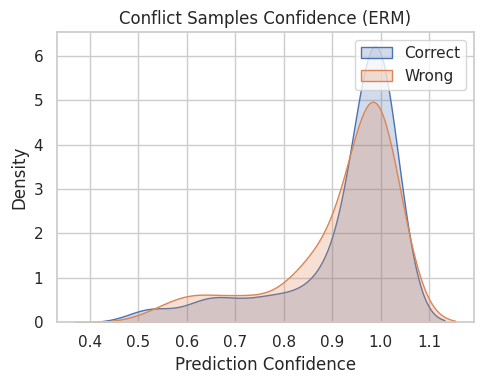

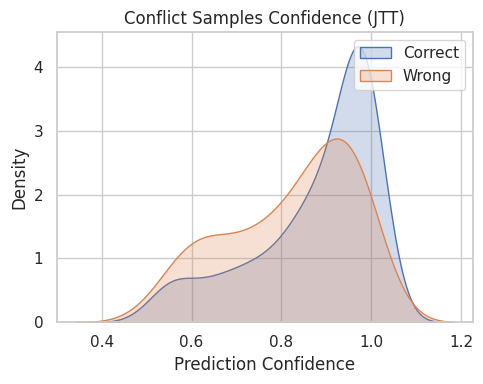

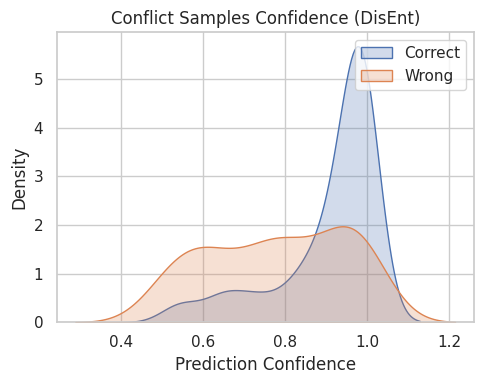

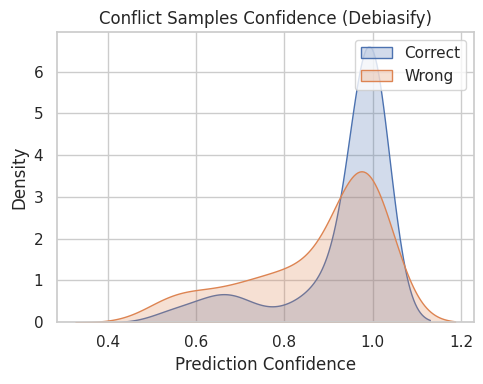

In [60]:
def plot_confidence_conflict(df, method_name, dataset_name):
    df = add_confidence_columns(df, dataset_name)
    conflict = df[~df.spurious]

    plt.figure(figsize=(5,4))
    sns.kdeplot(
        conflict[conflict["correct"] == 1]["p_max"],
        label="Correct",
        fill=True
    )
    sns.kdeplot(
        conflict[conflict["correct"] == 0]["p_max"],
        label="Wrong",
        fill=True
    )

    plt.xlabel("Prediction Confidence")
    plt.title(f"Conflict Samples Confidence ({method_name})")
    plt.legend()
    plt.tight_layout()
    plt.show()

# Waterbirds average confidence for conflict samples (non-spurious) by correct vs wrong predictions
plot_confidence_conflict(df_erm, "ERM", "waterbirds")
plot_confidence_conflict(df_jtt, "JTT", "waterbirds")
plot_confidence_conflict(df_disent, "DisEnt", "waterbirds")  
plot_confidence_conflict(df_debiasify, "Debiasify", "waterbirds")

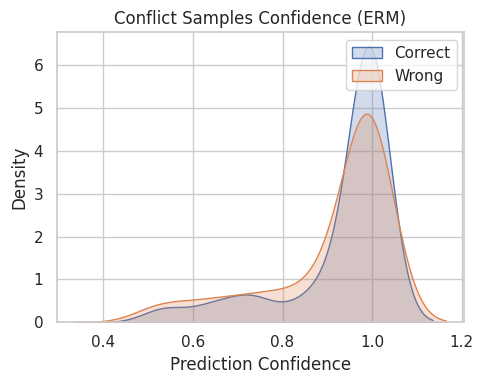

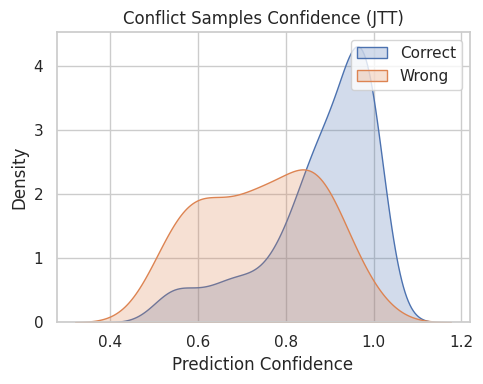

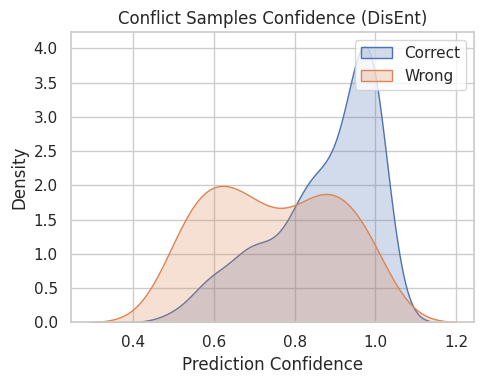

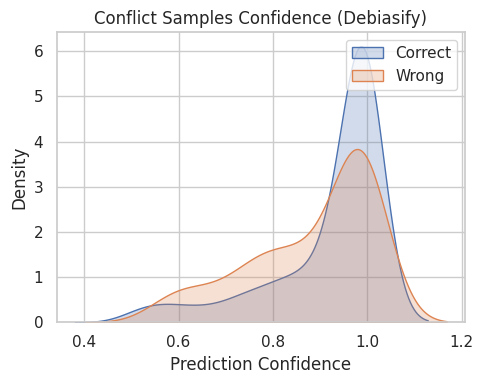

In [61]:
# Waterbirds worst group confidence for conflict samples (non-spurious) by correct vs wrong predictions
plot_confidence_conflict(df_erm_worst, "ERM", "waterbirds")
plot_confidence_conflict(df_jtt_worst, "JTT", "waterbirds")
plot_confidence_conflict(df_disent_worst, "DisEnt", "waterbirds")
plot_confidence_conflict(df_debiasify_worst, "Debiasify", "waterbirds")

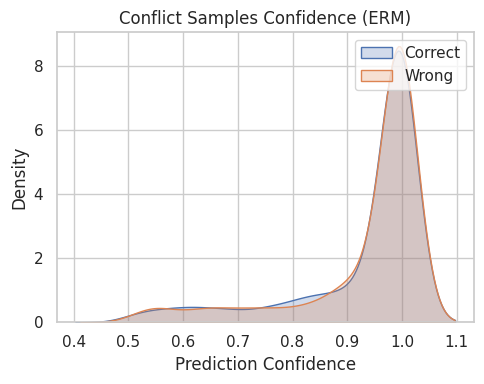

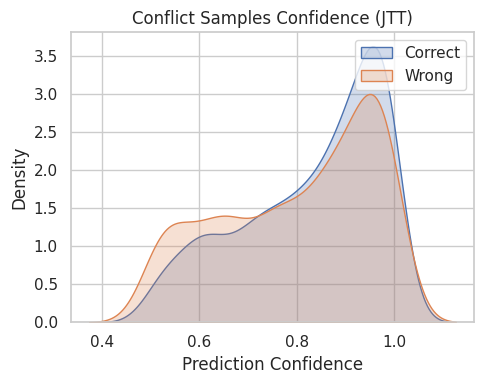

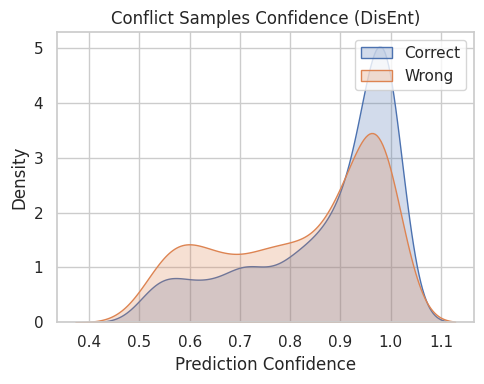

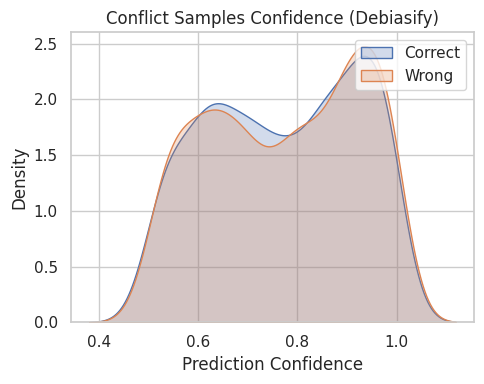

In [62]:
# FairFace average confidence for conflict samples (non-spurious) by correct vs wrong predictions
plot_confidence_conflict(df_erm_ff, "ERM", "fairface")
plot_confidence_conflict(df_jtt_ff, "JTT", "fairface")
plot_confidence_conflict(df_disent_ff, "DisEnt", "fairface")
plot_confidence_conflict(df_debiasify_ff, "Debiasify", "fairface")

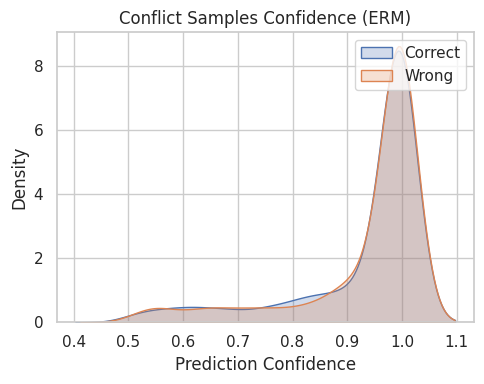

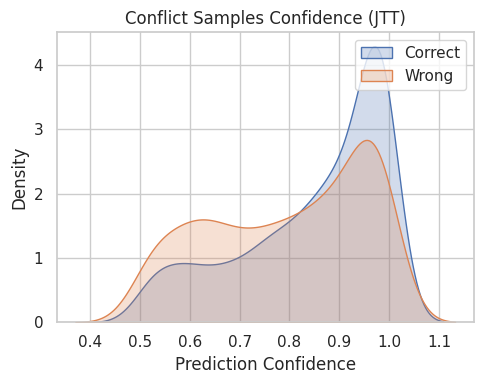

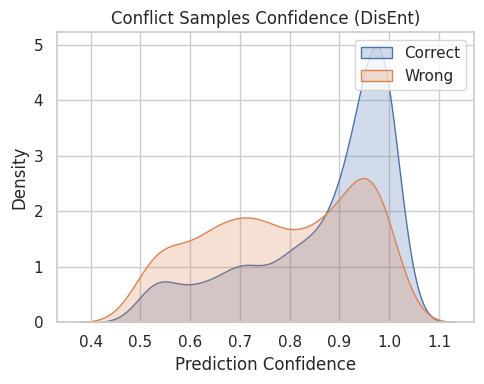

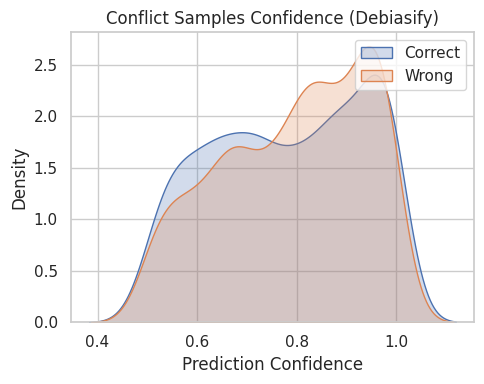

In [63]:
# FairFace worst group confidence for conflict samples (non-spurious) by correct vs wrong predictions
plot_confidence_conflict(df_erm_ff_worst, "ERM", "fairface")
plot_confidence_conflict(df_jtt_ff_worst, "JTT", "fairface")
plot_confidence_conflict(df_disent_ff_worst, "DisEnt", "fairface")
plot_confidence_conflict(df_debiasify_ff_worst, "Debiasify", "fairface")

### Group-wise Prediction Confidence ($p_{max}$)
How confident was the model in its predicted class within each $(y, a)$ group?
The plots below split confidence by group and predicted label.

In [64]:
def add_groupwise_plot_columns(df, dataset_name):
    cfg = DATASET_CONFIG[dataset_name]
    group_map = {(y, a): name for y, a, name in cfg["groups"]}

    out = df.copy()
    out["group"] = out.apply(
        lambda r: group_map.get((int(r.y_true), int(r.attr_true)), f"({int(r.y_true)}, {int(r.attr_true)})"),
        axis=1,
    )
    out["pred_label"] = out["y_pred"].map(cfg["y_map"]).fillna(out["y_pred"].astype(str))

    # Keep group order stable across plots for easier method comparison.
    group_order = [name for _, _, name in cfg["groups"]]
    out["group"] = pd.Categorical(out["group"], categories=group_order, ordered=True)
    return out


def plot_groupwise_pmax_density(
    df, method_name, dataset_name, fill=True, normalize="within_group"
 ):
    plot_df = add_groupwise_plot_columns(df, dataset_name)

    if normalize not in {"global", "within_group"}:
        raise ValueError("normalize must be 'global' or 'within_group'")

    # global: all KDE curves share one normalization across facets for direct comparison.
    # within_group: each facet has its own normalization (shape comparison inside each group).
    common_norm = normalize == "global"

    g = sns.displot(
        data=plot_df,
        x="p_1",
        hue="pred_label",
        col="group",
        col_wrap=2,
        kind="kde",
        fill=fill,
        common_norm=common_norm,
        common_grid=True,
        facet_kws={"sharex": True, "sharey": True},
        height=3.2,
        aspect=1.35,
    )
    norm_label = "global-normalized" if common_norm else "normalized within each group"
    g.set(xlabel="Predicted-class confidence ($p_{max}$)", ylabel="Density")
    g.fig.subplots_adjust(top=0.86)
    g.fig.suptitle(
        f"Group-wise $p_{{1}}$ density by predicted label ({method_name}, {norm_label})"
    )
    plt.show()

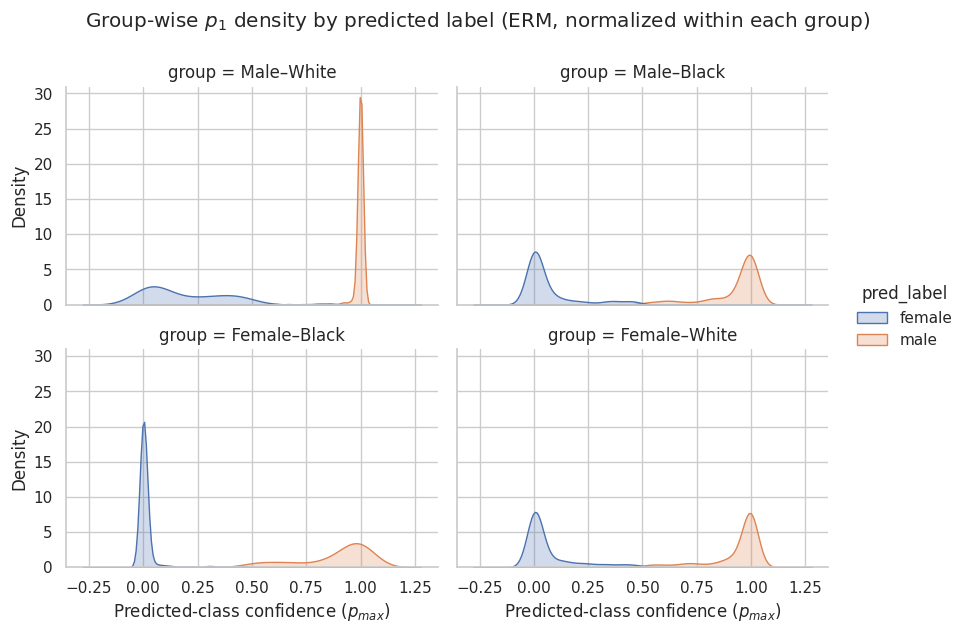

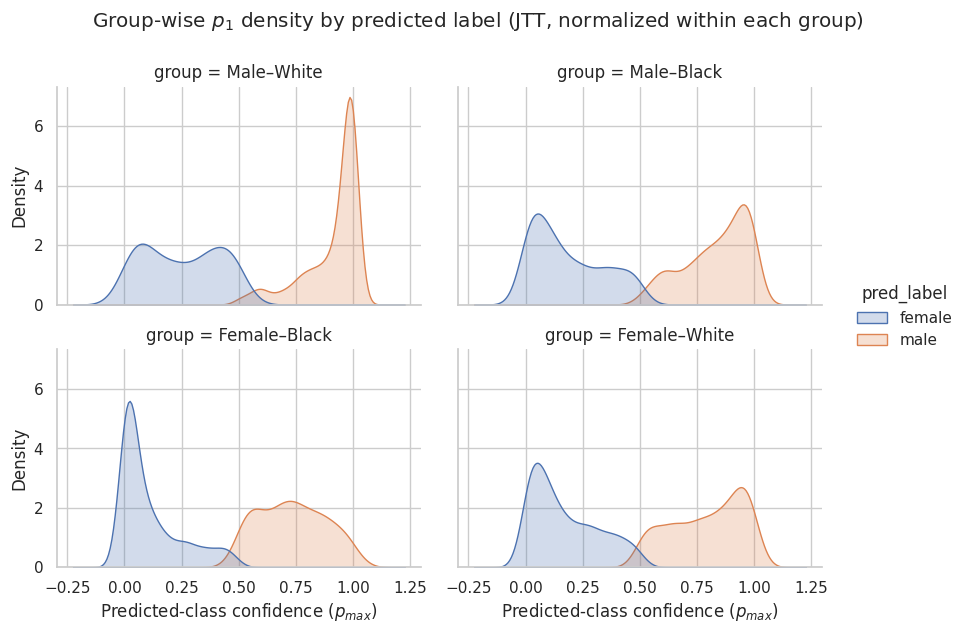

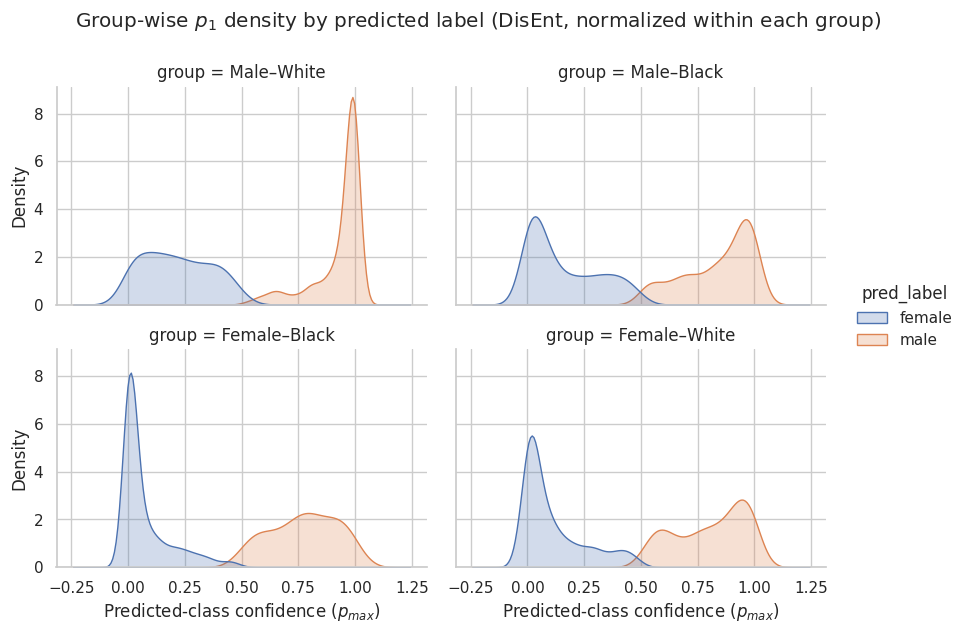

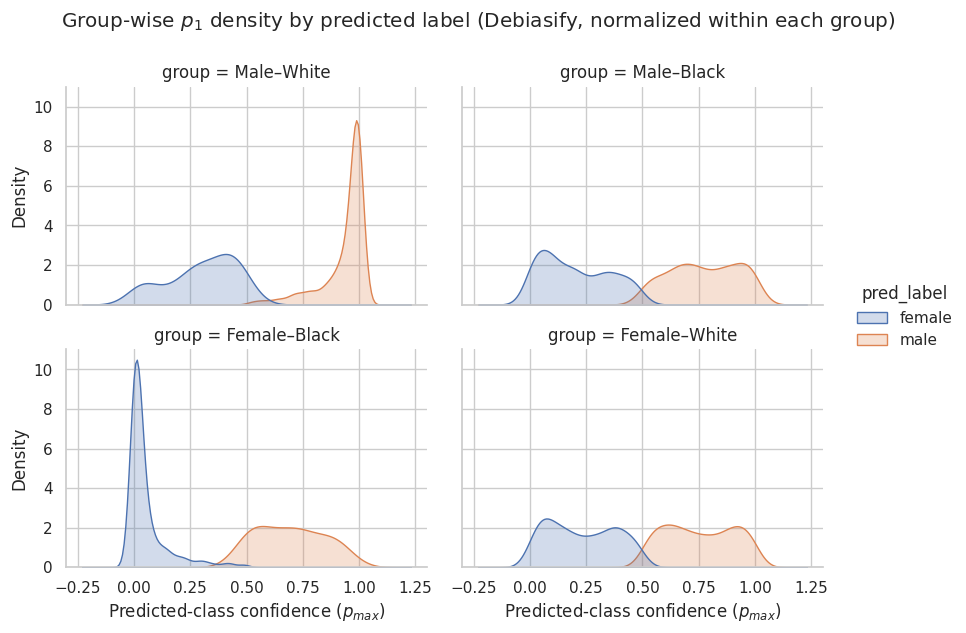

In [65]:
for method_name, df_method in [
    ("ERM", df_erm_ff),
    ("JTT", df_jtt_ff),
    ("DisEnt", df_disent_ff),
    ("Debiasify", df_debiasify_ff),
]:
    plot_groupwise_pmax_density(df_method, method_name, "fairface")

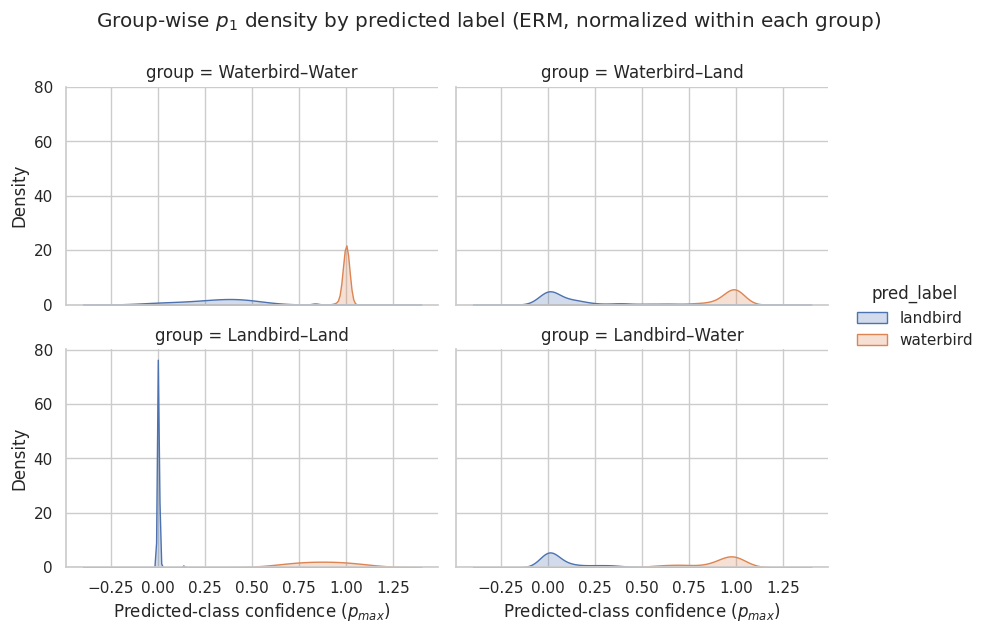

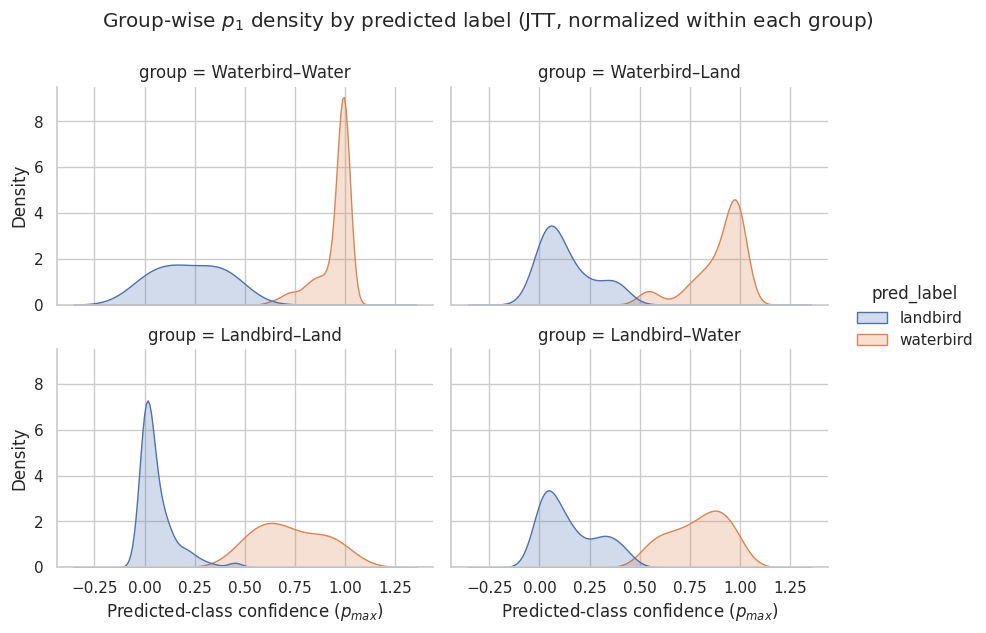

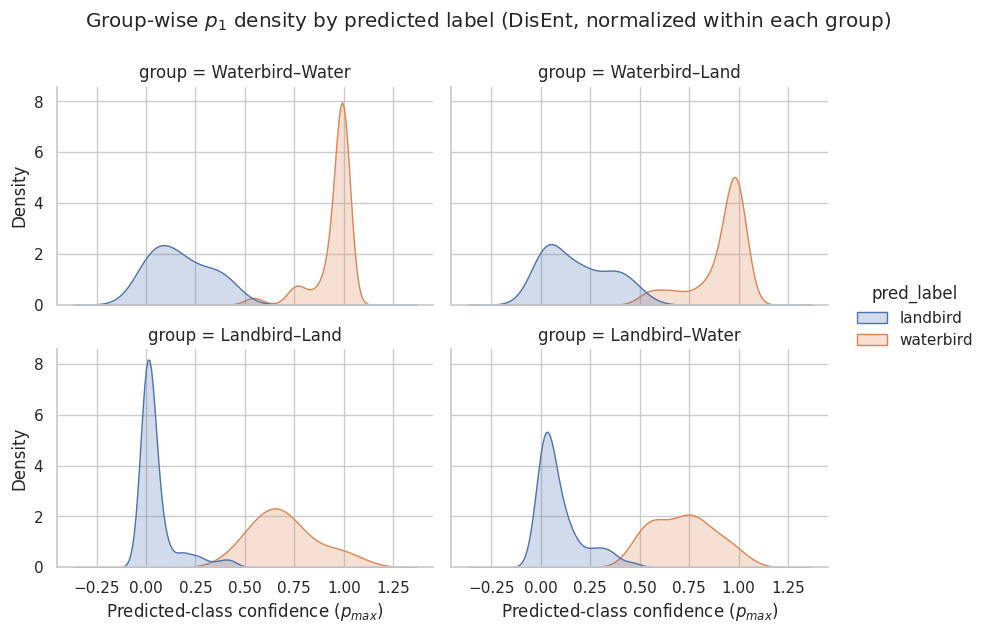

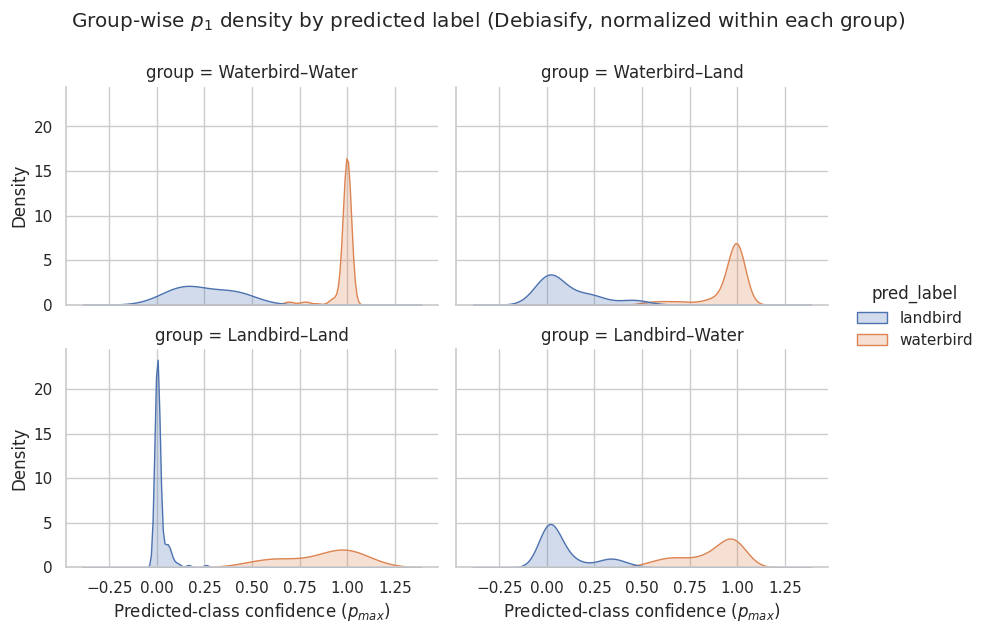

In [66]:
for method_name, df_method in [
    ("ERM", df_erm),
    ("JTT", df_jtt),
    ("DisEnt", df_disent),
    ("Debiasify", df_debiasify),
]:
    plot_groupwise_pmax_density(df_method, method_name, "waterbirds")

### Confidence Split by Spurious × Correctness

In [67]:
def table_confidence_joint(df, method_name, dataset_name):
    df = add_confidence_columns(df, dataset_name)

    rows = [{
        "Method": method_name,
        "Mean conf (correct, spurious)":
            df[(df.correct) & (df.spurious)]["p_true"].mean(),
        "Mean conf (correct, non-spurious)":
            df[(df.correct) & (~df.spurious)]["p_true"].mean(),
        "Mean conf (wrong, spurious)":
            df[(~df.correct) & (df.spurious)]["p_true"].mean(),
        "Mean conf (wrong, non-spurious)":
            df[(~df.correct) & (~df.spurious)]["p_true"].mean(),
    }]

    return pd.DataFrame(rows)

pd.concat([
    table_confidence_joint(df_erm, "ERM", "waterbirds"),
    table_confidence_joint(df_jtt, "JTT", "waterbirds"),
    table_confidence_joint(df_disent, "DisEnt", "waterbirds"),
    table_confidence_joint(df_debiasify, "Debiasify", "waterbirds"),
])

,Method,"Mean conf (correct, spurious)","Mean conf (correct, non-spurious)","Mean conf (wrong, spurious)","Mean conf (wrong, non-spurious)"
0,ERM,0.994293,0.924555,0.260408,0.088174
0,JTT,0.944181,0.875282,0.251779,0.178448
0,DisEnt,0.947915,0.906449,0.221487,0.220721
0,Debiasify,0.984236,0.930055,0.189173,0.126434


In [68]:
pd.concat([
    table_confidence_joint(df_erm_worst, "ERM", "waterbirds"),
    table_confidence_joint(df_jtt_worst, "JTT", "waterbirds"),
    table_confidence_joint(df_disent_worst, "DisEnt", "waterbirds"),
    table_confidence_joint(df_debiasify_worst, "Debiasify", "waterbirds"),
])

,Method,"Mean conf (correct, spurious)","Mean conf (correct, non-spurious)","Mean conf (wrong, spurious)","Mean conf (wrong, non-spurious)"
0,ERM,0.998679,0.930770,0.109777,0.090126
0,JTT,0.884310,0.876544,0.292716,0.255177
0,DisEnt,0.886045,0.870339,0.294159,0.253044
0,Debiasify,0.983571,0.919634,0.136680,0.117977


In [69]:
pd.concat([
    table_confidence_joint(df_erm_ff, "ERM", "fairface"),
    table_confidence_joint(df_jtt_ff, "JTT", "fairface"),
    table_confidence_joint(df_disent_ff, "DisEnt", "fairface"),
    table_confidence_joint(df_debiasify_ff, "Debiasify", "fairface"),  
])

,Method,"Mean conf (correct, spurious)","Mean conf (correct, non-spurious)","Mean conf (wrong, spurious)","Mean conf (wrong, non-spurious)"
0,ERM,0.987641,0.930372,0.148387,0.066880
0,JTT,0.900705,0.829873,0.258943,0.198972
0,DisEnt,0.927683,0.869556,0.219893,0.177683
0,Debiasify,0.937855,0.770911,0.303527,0.225270


In [70]:
pd.concat([
    table_confidence_joint(df_erm_ff_worst, "ERM", "fairface"),
    table_confidence_joint(df_jtt_ff_worst, "JTT", "fairface"),
    table_confidence_joint(df_disent_ff_worst, "DisEnt", "fairface"),
    table_confidence_joint(df_debiasify_ff_worst, "Debiasify", "fairface"),
])

,Method,"Mean conf (correct, spurious)","Mean conf (correct, non-spurious)","Mean conf (wrong, spurious)","Mean conf (wrong, non-spurious)"
0,ERM,0.987641,0.930372,0.148387,0.066880
0,JTT,0.845706,0.849056,0.194428,0.203936
0,DisEnt,0.866185,0.866742,0.230586,0.214841
0,Debiasify,0.940399,0.780950,0.295101,0.207575
